<a href="https://colab.research.google.com/github/Atharv-Chopade/Machine_Learning/blob/main/AdaBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
from sklearn.datasets import load_breast_cancer

In [12]:
data = load_breast_cancer()
X = data.data
y = data.target

In [13]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train ,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [14]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier(n_estimators = 50 , learning_rate= 20)
model.fit(X_train , y_train)
y_pred = model.predict(X_test)

Before Scaling


In [15]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test , y_pred)

0.8947368421052632

After Scaling

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
model1 = AdaBoostClassifier(n_estimators = 50 , learning_rate= 20)
model1.fit(X_train_scaled , y_train)
y_pred1 = model1.predict(X_test_scaled)
accuracy_score(y_test , y_pred1)

0.8947368421052632

Q1

Train an AdaBoost classifier with 50 estimators on the Breast Cancer dataset.

In [37]:
model = AdaBoostClassifier(n_estimators = 50 , learning_rate= 20)
model.fit(X_train , y_train)
y_pred = model.predict(X_test)
print(model.feature_importances_)

[0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]


Q2

Print the model accuracy.

In [38]:
m1_acc = accuracy_score(y_test , y_pred)

Q3

Change n_estimators from 50 to 100 and compare the accuracy.

In [39]:
model1 = AdaBoostClassifier(n_estimators = 100 , learning_rate= 20)
model1.fit(X_train , y_train)
y_pred1 = model1.predict(X_test)
m2_acc = accuracy_score(y_test , y_pred1)

print(model1.feature_importances_)

[0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]


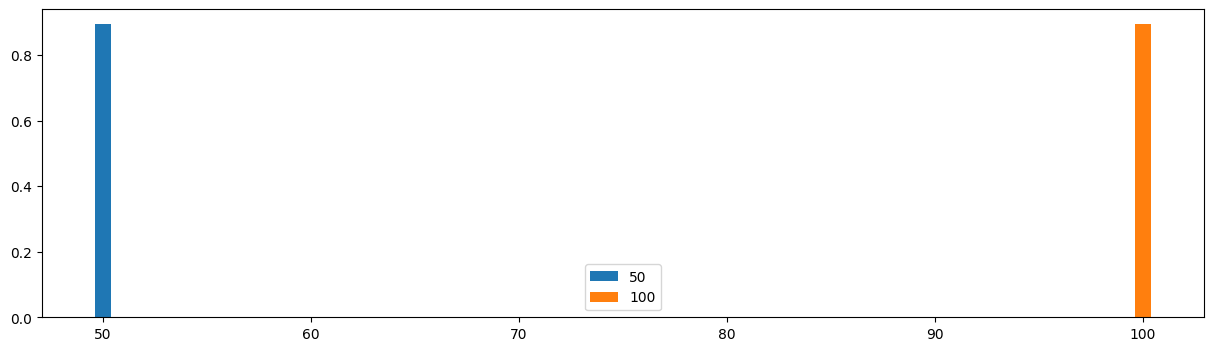

In [40]:
plt.figure(figsize= (15 , 4))
plt.bar(50 , m1_acc , label = '50')
plt.bar(100 , m2_acc , label = '100')
plt.legend()
plt.show()

Q4

Try different values of learning_rate (0.1, 0.5, 1.0).

In [41]:
lr = [0.1 , 0.5 , 1.0]
acclr = []
for i in lr:
  model = AdaBoostClassifier(n_estimators = 50 , learning_rate= i)
  model.fit(X_train , y_train)
  y_pred = model.predict(X_test)
  acclr.append(accuracy_score(y_test, y_pred))


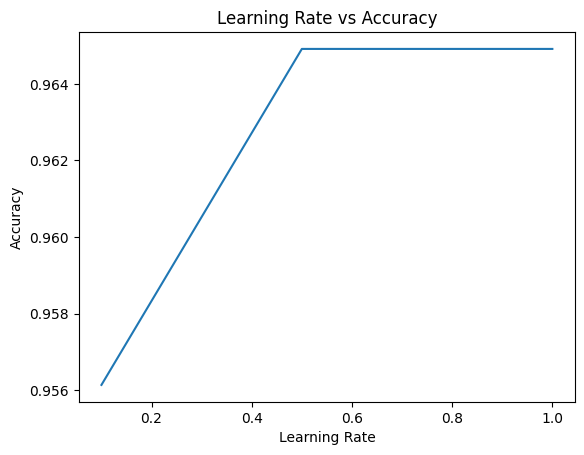

In [42]:
plt.plot(lr , acclr)
plt.title("Learning Rate vs Accuracy")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.show()

In [44]:
import seaborn as sns

In [49]:
model.feature_importances_

array([0.        , 0.06926252, 0.        , 0.        , 0.01992673,
       0.0178256 , 0.        , 0.10152852, 0.0592247 , 0.01448986,
       0.01849122, 0.        , 0.        , 0.04465856, 0.0304841 ,
       0.06579934, 0.        , 0.        , 0.02563839, 0.        ,
       0.        , 0.08322844, 0.03098204, 0.14120235, 0.0648929 ,
       0.01202091, 0.05210853, 0.07018233, 0.07805295, 0.        ])

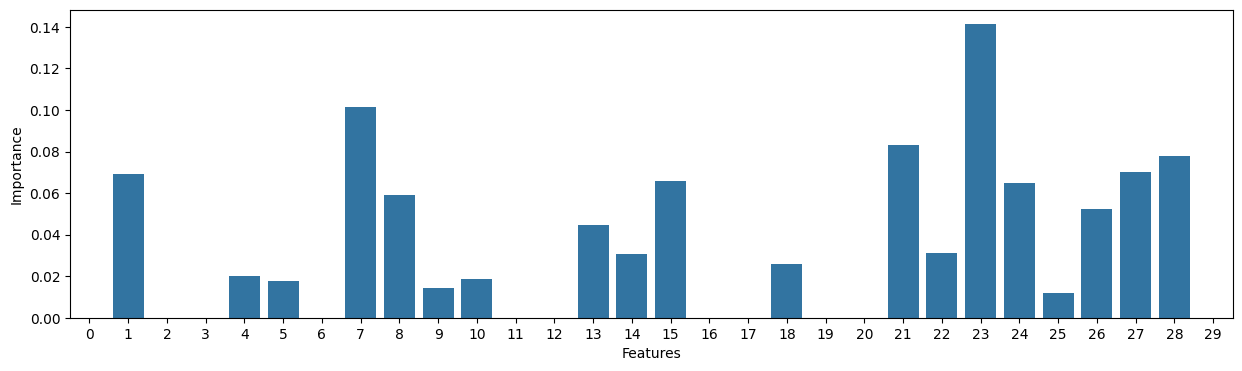

In [48]:
plt.figure(figsize = (15, 4))
sns.barplot(model.feature_importances_)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()